In [1]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import seaborn as sns
sys.path.append('../bin')
from bin.functions import *
from bin.permutation import *
from bin.markov_permutation import *
from bin.entropy import *
from bin.criterions import *
from scipy.stats import chi2_contingency
np.seterr(all = 'ignore')

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

In [3]:
x = np.linspace(0, 10, 100)
y = np.sin(x)

plt.style.use('seaborn-lightgrid')

plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Sine Wave', color='blue', linewidth=2)

plt.title('Scientific Visualization Example', fontsize=16)
plt.xlabel('X Axis', fontsize=14)
plt.ylabel('Y Axis', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)

#plt.savefig('scientific_visualization_styled.png', dpi=300)
plt.show()


OSError: 'seaborn-lightgrid' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

In [5]:
ts = generate_rw(10000)
p_ts = count_permutation(ts, 3)
p_ts

[2499, 1180, 1202, 1302, 1280, 2535]

In [106]:
x = [1/4, 1/8, 1/8, 1/8, 1/8, 1/4]
r = list(range(3))
permutation_list = list(it.permutations(r))


In [107]:
permutation_list = ["(0, 1, 2)", "(0, 2, 1)", "(1, 0, 2)", "(1, 2, 0)", "(2, 0, 1)", "(2, 1, 0)"]

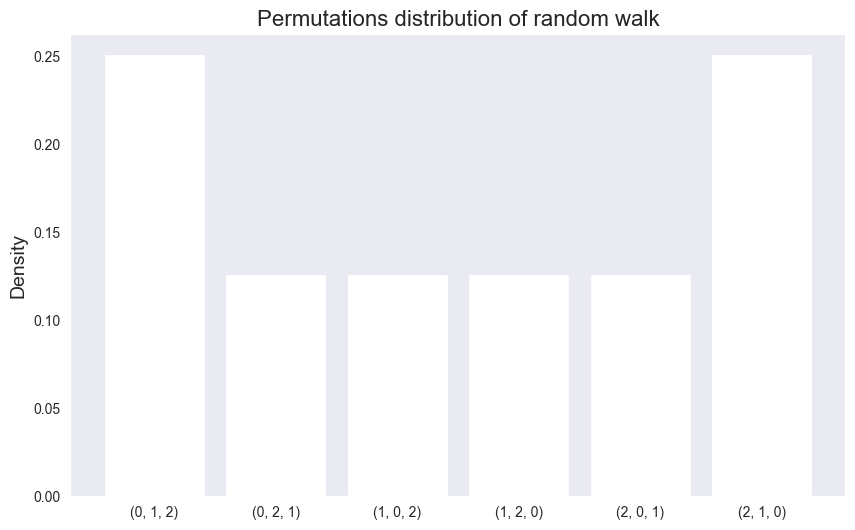

In [108]:
plt.figure(figsize=(10, 6))
plt.bar(x=permutation_list, height= x, linewidth=2, facecolor='white')
plt.title('Permutations distribution of random walk', fontsize=16)
plt.ylabel('Density', fontsize=14)
#plt.legend(fontsize=12)
plt.grid(False)

plt.savefig('dist_rw.png', dpi=300)
plt.show()

In [52]:
r = list(range(4))
permutation_list = list(map(str,list(it.permutations(r))))
permutation_list

['(0, 1, 2, 3)',
 '(0, 1, 3, 2)',
 '(0, 2, 1, 3)',
 '(0, 2, 3, 1)',
 '(0, 3, 1, 2)',
 '(0, 3, 2, 1)',
 '(1, 0, 2, 3)',
 '(1, 0, 3, 2)',
 '(1, 2, 0, 3)',
 '(1, 2, 3, 0)',
 '(1, 3, 0, 2)',
 '(1, 3, 2, 0)',
 '(2, 0, 1, 3)',
 '(2, 0, 3, 1)',
 '(2, 1, 0, 3)',
 '(2, 1, 3, 0)',
 '(2, 3, 0, 1)',
 '(2, 3, 1, 0)',
 '(3, 0, 1, 2)',
 '(3, 0, 2, 1)',
 '(3, 1, 0, 2)',
 '(3, 1, 2, 0)',
 '(3, 2, 0, 1)',
 '(3, 2, 1, 0)']

In [29]:
ts = generate_rw(1000)
p_ts = count_permutation(ts, 4)
print(np.array(p_ts)/1000)

[0.123 0.068 0.044 0.032 0.02  0.027 0.062 0.027 0.02  0.024 0.007 0.036
 0.034 0.016 0.026 0.022 0.025 0.065 0.029 0.016 0.037 0.039 0.066 0.132]


In [35]:
0.018229166666666668*12+3/64*6

0.5

In [62]:
x = [0.125, 0.125/2, 3/64, 3/64, 0.018229166666666668,  0.018229166666666668, 0.125/2, 0.018229166666666668, 0.018229166666666668,  0.018229166666666668, 0.018229166666666668, 3/64, 3/64, 0.018229166666666668, 0.018229166666666668, 0.018229166666666668, 0.018229166666666668, 0.125/2, 0.018229166666666668, 0.018229166666666668, 3/64, 3/64, 0.125/2, 0.125]

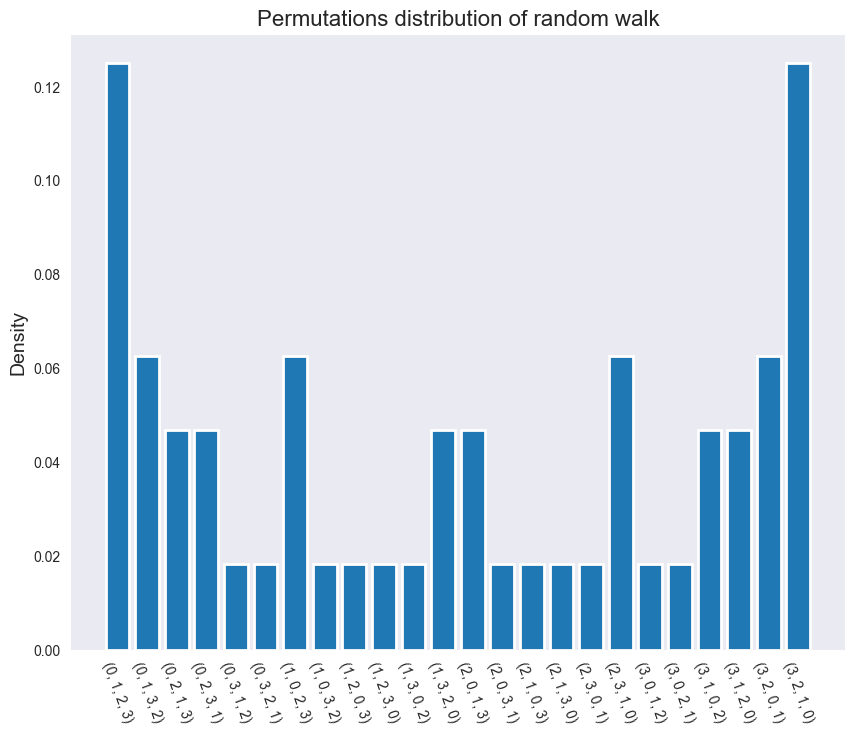

In [56]:
plt.figure(figsize=(10, 8))
plt.bar(x=permutation_list, height= x, linewidth=2 )

plt.title('Permutations distribution of random walk', fontsize=16)
plt.ylabel('Density', fontsize=14)
#plt.legend(fontsize=12)
plt.grid(False)
plt.xticks(rotation=290)
plt.savefig('dist_rw4.png')
plt.show()

In [60]:
2*(1/4*np.log2(1/4))+4*(1/8*np.log2(1/8))

-2.5

In [61]:
np.log2(6)

2.584962500721156

In [63]:
entropy(x, relative=False)

4.255580954504826

In [64]:
np.log2(24)

4.584962500721156

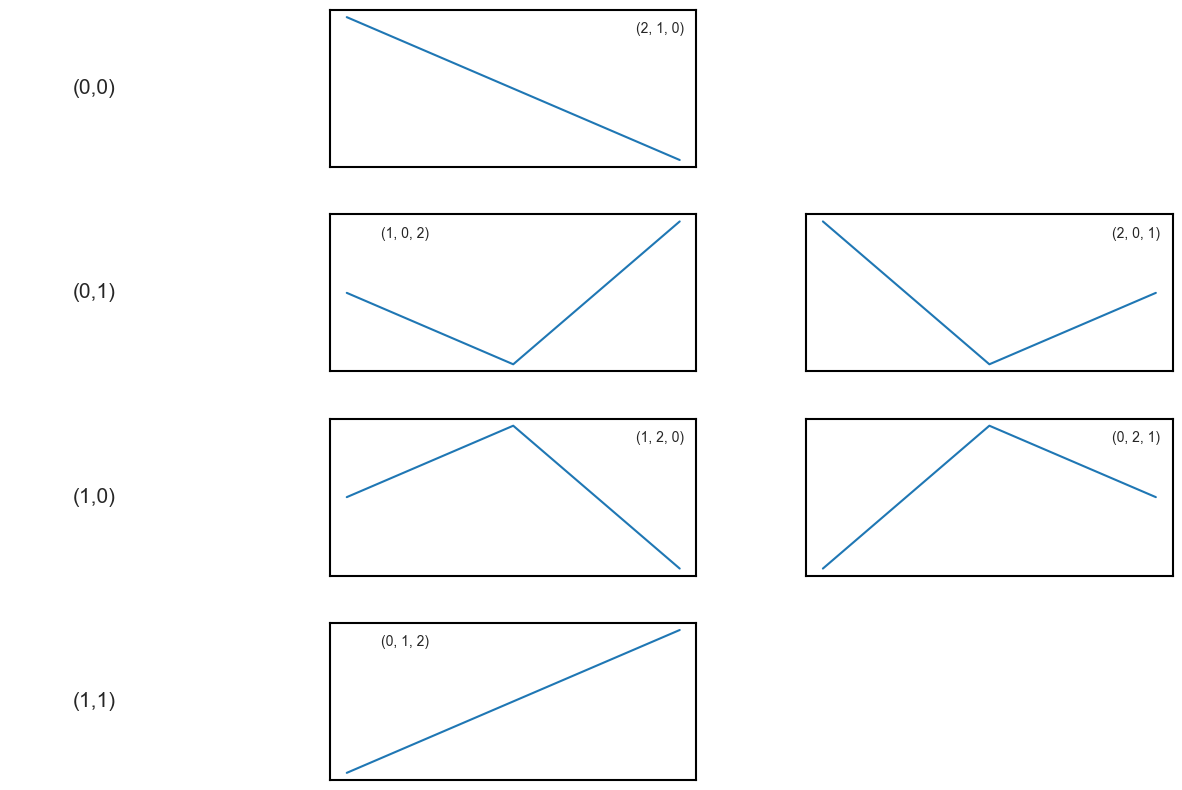

In [105]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

data = {
    "(0,0)": [([1, 2, 3], [3, 2, 1])],
    "(0,1)": [([1, 2, 3], [2, 1, 3]), ([1, 2, 3], [3, 1, 2])],
    "(1,0)": [([1, 2, 3], [2, 3, 1]), ([1, 2, 3], [1, 3, 2])],
    "(1,1)": [([1, 2, 3], [1, 2, 3])],
}
# Настройка размерности фигуры и сетки
fig = plt.figure(figsize=(15, 10))
outer = gridspec.GridSpec(len(data), 2, width_ratios=[1, 5], wspace=0.3, hspace=0.3)

for i, (word, plots) in enumerate(data.items()):
    # Место для слова
    word_ax = plt.Subplot(fig, outer[i * 2])
    word_ax.text(0.5, 0.5, word, fontsize=15, ha='center', va='center')
    word_ax.set_xticks([])
    word_ax.set_yticks([])
    word_ax.set_facecolor('white')
    fig.add_subplot(word_ax)
    
    # Место для трех графиков
    inner = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[i * 2 + 1], wspace=0.3)
    
    for j, (x, y) in enumerate(plots):
        ax = plt.Subplot(fig, inner[j])
        ax.plot(x, y)
        legend_element = plt.Line2D([0], [0], linestyle="none", label="("+str(((np.array(y)-1).tolist()))[1:-1]+")")
        ax.legend(handles=[legend_element], frameon=False)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_facecolor('white')
        for spine in ax.spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(1.5)
        fig.add_subplot(ax)
plt.savefig('form_perm3.png')
plt.show()


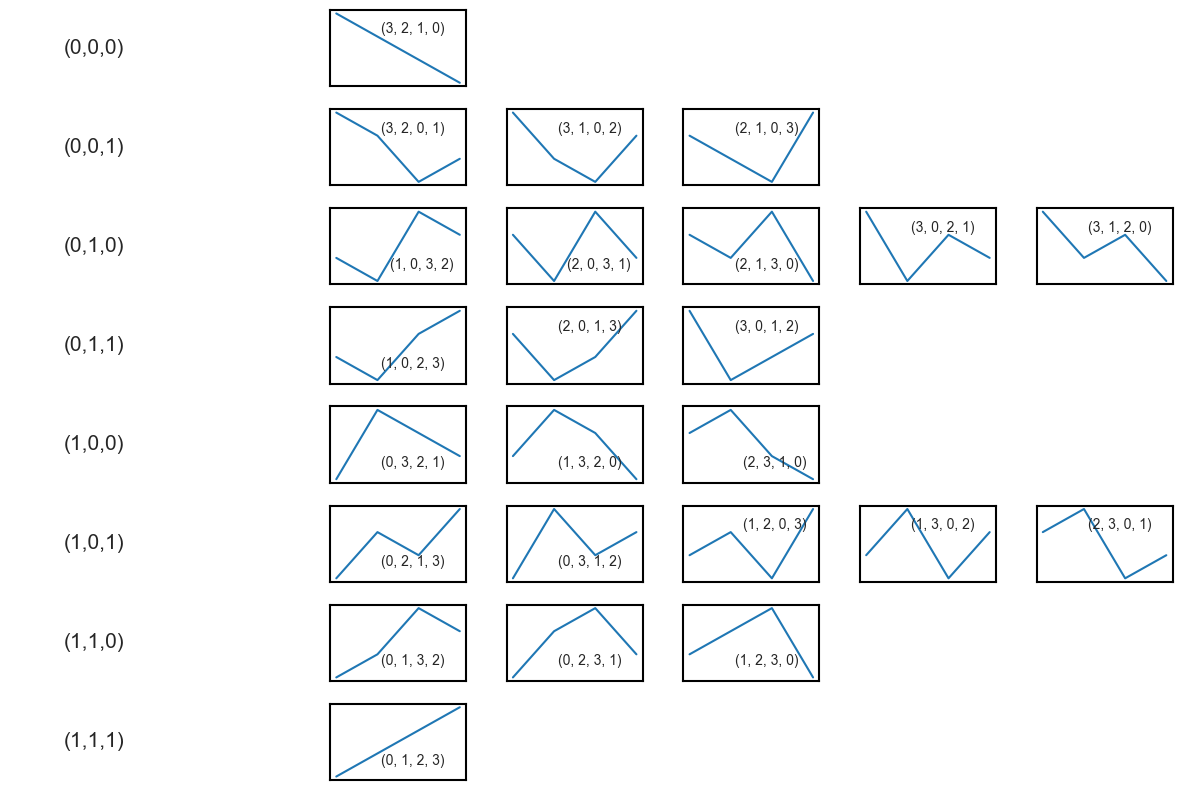

In [104]:
data = {
    "(0,0,0)": [([1, 2, 3, 4], [4, 3, 2, 1])],
    "(0,0,1)": [([1, 2, 3, 4], [4, 3, 1, 2]), ([1, 2, 3, 4], [4, 2, 1, 3]), ([1, 2, 3, 4], [3, 2, 1, 4])],
    "(0,1,0)": [([1, 2, 3, 4], [2, 1, 4, 3]), ([1, 2, 3, 4], [3, 1, 4, 2]), ([1, 2, 3, 4], [3, 2, 4, 1]), ([1, 2, 3, 4], [4, 1, 3, 2]), ([1, 2, 3, 4], [4, 2, 3, 1])],
    "(0,1,1)": [([1, 2, 3, 4], [2, 1, 3, 4]), ([1, 2, 3, 4], [3, 1, 2, 4]), ([1, 2, 3, 4], [4, 1, 2, 3])],
    "(1,0,0)": [([1, 2, 3, 4], [1, 4, 3, 2]), ([1, 2, 3, 4], [2, 4, 3, 1]), ([1, 2, 3, 4], [3, 4, 2, 1])],
    "(1,0,1)": [([1, 2, 3, 4], [1, 3, 2, 4]), ([1, 2, 3, 4], [1, 4, 2, 3]), ([1, 2, 3, 4], [2, 3, 1, 4]), ([1, 2, 3, 4], [2, 4, 1, 3]), ([1, 2, 3, 4], [3, 4, 1, 2])],
    "(1,1,0)": [([1, 2, 3, 4], [1, 2, 4, 3]), ([1, 2, 3, 4], [1, 3, 4, 2]), ([1, 2, 3, 4], [2, 3, 4, 1])],
    "(1,1,1)": [([1, 2, 3, 4], [1, 2, 3, 4])],
}
labels = [['upper left'],
          ['upper left', 'upper left','upper left'],
          ['lower right','lower right','lower left','upper left','upper left'],
          ['lower left','upper left','upper left'],
          ['lower left','lower left','lower right'],
          ['lower left', 'lower left','upper right','upper left','upper left'],
          ['lower left','lower left','lower left'],
          ['lower left']]
# Настройка размерности фигуры и сетки
fig = plt.figure(figsize=(15, 10))
outer = gridspec.GridSpec(len(data), 2, width_ratios=[1, 5], wspace=0.3, hspace=0.3)

for i, (word, plots) in enumerate(data.items()):
    # Место для слова
    word_ax = plt.Subplot(fig, outer[i * 2])
    word_ax.text(0.5, 0.5, word, fontsize=15, ha='center', va='center')
    word_ax.set_xticks([])
    word_ax.set_yticks([])
    word_ax.set_facecolor('white')
    fig.add_subplot(word_ax)
    
    # Место для трех графиков
    inner = gridspec.GridSpecFromSubplotSpec(1, 5, subplot_spec=outer[i * 2 + 1], wspace=0.3)
    
    for j, (x, y) in enumerate(plots):
        ax = plt.Subplot(fig, inner[j])
        ax.plot(x, y)
        legend_element = plt.Line2D([0], [0], linestyle="none", label="("+str(((np.array(y)-1).tolist()))[1:-1]+")")
        ax.legend(handles=[legend_element], frameon=False, loc=labels[i][j])
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_facecolor('white')
        for spine in ax.spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(1.5)
        fig.add_subplot(ax)
plt.savefig('form_perm4.png')
plt.show()


In [93]:
r = list(range(4))
permutation_list = list(it.permutations(r))
for perm in permutation_list:
    if perm[0]<perm[1] and perm[1] < perm[2] and perm[2] > perm[3]:
        print((np.array(perm)+1).tolist())

[1, 2, 4, 3]
[1, 3, 4, 2]
[2, 3, 4, 1]


In [4]:
res = chi2_contingency([[15,50,5], [10,5,100]])
chi2_stat, p_value = res.statistic, res.pvalue
print(chi2_stat, p_value)

119.91995375225187 9.114081496582193e-27


In [5]:
res = chi2_contingency([[15/70,50/70,5/70], [10/115,5/115,100/115]])
chi2_stat, p_value = res.statistic, res.pvalue
print(chi2_stat, p_value)

1.3246164907178568 0.5156596906298991


In [2]:
ts = generate_rw(10)
print(ts)
count_shapes(ts, 3)

[-1.01432999  1.03567681  1.07647777  1.28406848  1.41383853  3.00229519
  2.29109383  2.64913089  3.44420899  3.43342817]


[0, 1, 2, 5]

In [3]:
shape_series(ts, 3)

0    3
1    3
2    3
3    3
4    2
5    1
6    3
7    2
dtype: int64

In [6]:
k=0
for i in range(100):
    ts = generate_rw(100)
    if double_equals_test(ts) == False:
        k+=1
print(k)

6


In [12]:
k=0
for i in range(30):
    ts = generate_arma(2, 0, 1000)
    if double_equals_test(ts) == False:
        k+=1
print(k)

0


In [11]:
ts = generate_rw(1000)
double_chi2_test(ts)

False

In [219]:
ts = generate_rw(5000)
chi_square_test(count_shapes(ts,4), alpha=0.2)

[624.625 624.625 624.625 624.625 624.625 624.625 624.625 624.625]
[650, 625, 641, 615, 626, 631, 615, 594]


(True, 0.9758298651940231, 1.67011193888143, 3.8223219077661383)

In [234]:
_, ts = generate_trend_series(5000)
chi_square_test(count_shapes(ts,4), alpha=0.2)

[624.625 624.625 624.625 624.625 624.625 624.625 624.625 624.625]
[0, 9, 53, 447, 9, 492, 448, 3539]


(False, 0.0, 4417.331187522088, 3.8223219077661383)

In [2]:
def create_dataset_df(num_series=100000, series_length=1000):
    """
    Создание датасета, содержащего временные ряды разных типов в виде DataFrame.
    
    Параметры:
    - num_series: int, количество временных рядов каждого типа
    - series_length: int, длина каждого временного ряда
    
    Возвращает:
    - dataset: dict, содержащий временные ряды разных типов в виде DataFrame
    """
    dataset = {}
    
    # Создание авторегрессионных временных рядов с малой памятью
    ar2_series = []
    for _ in range(num_series):
        time_series = np.random.randint(-100, 100) + generate_arma(p=2, q=0, n=series_length)
        ar2_series.append(time_series)
    dataset['ar2'] = pd.DataFrame(ar2_series)
    
    # Создание авторегрессионных временных рядов с большой памятью
    arma_series = []
    for _ in range(num_series):
        time_series = np.random.randint(-100, 100) + generate_arma(p=10, q=5, n=series_length)
        arma_series.append(time_series)
    dataset['arma'] = pd.DataFrame(arma_series)
    
    # Создание мультифрактальных временных рядов
    multifractal_series = []
    for _ in range(num_series):
        time_series = generate_multifractal(series_length, H=np.random.rand())
        multifractal_series.append(time_series)
    dataset['multifractal'] = pd.DataFrame(multifractal_series)
    
    # Создание трендовых временных рядов
    cos_series = []
    ts_n_series = []
    for _ in range(num_series):
        ts_n, time_series = generate_trend_series(length=series_length, trend_koef=np.random.uniform(low=0, high=0.6), ampl=np.random.uniform(low=0, high=1.5), seasonality_period=12, seasonality_aplitude=np.random.uniform(low=0, high=0.5), sigma=np.random.uniform(low=0.2,high=0.5))
        ts_n_series.append(ts_n)
        cos_series.append(time_series)
    dataset['trend_cos'] = pd.DataFrame(cos_series)
    
    # Создание случайных блужданий
    rand_wolk_series = []

    for _ in range(num_series):
        time_series = np.random.uniform(low=-50, high=50) + generate_rw(series_length)
        rand_wolk_series.append(time_series)
    dataset['random_walk'] = pd.DataFrame(rand_wolk_series)
    
    return dataset, pd.DataFrame(ts_n_series)

In [3]:
def calculate_characteristics(dataset_df):
    """
    Вычисление характеристик для каждого временного ряда в датасете и сохранение их в датафрейме.
    
    Параметры:
    - dataset_df: dict, содержащий временные ряды разных типов в виде DataFrame
    
    Возвращает:
    - characteristics_df: DataFrame, содержащий характеристики для каждого временного ряда
    """
    characteristics = {}
    
    # Вычисление характеристик для каждого типа временного ряда
    for key, df in dataset_df.items():
        print(key)
        characteristics[key + '_perm_ent3'] = df.apply(permutation_entropy, args=(3,), axis=1)
        characteristics[key + '_perm_ent4'] = df.apply(permutation_entropy, args=(4,), axis=1)
        characteristics[key + '_shape_ent3'] = df.apply(shape_entropy, args=(3,), axis=1)
        characteristics[key + '_shape_ent4'] = df.apply(shape_entropy, args=(4,), axis=1)
        characteristics[key + '_shape_ent5'] = df.apply(shape_entropy, args=(5,), axis=1)
        
        
    # Создание датафрейма с характеристиками
    characteristics_df = pd.DataFrame(characteristics)
    
    return characteristics_df

In [4]:
dataset_df, trend_series_wo_noise = create_dataset_df(num_series=100, series_length=500)

In [5]:
characteristics_df = calculate_characteristics(dataset_df)

ar2
arma
multifractal
trend_cos
random_walk


In [6]:
def make_forecast(dataset, forecast_func, forecast_length):
    """
    Make forecasts for each time series in the dataset.

    Parameters:
        dataset (pandas.DataFrame): Input dataset where each row represents a time series.
        forecast_func (function): Function for making forecasts. This function should take a time series
                                  as input and return the forecasted values.
        forecast_length (int): Length of the forecast horizon.

    Returns:
        pandas.DataFrame: DataFrame containing the forecasted values.
    """
    # Create an empty DataFrame to store the forecasted values
    forecasted_dataset = pd.DataFrame(columns=dataset.columns[len(dataset.columns)-forecast_length:])

    # Iterate over each row (time series) in the dataset
    for index, row in dataset.iterrows():
        # Extract the time series
        time_series = row.values
        
        # Make the forecast using the provided function
        forecast = forecast_func(time_series[:len(time_series) - forecast_length], forecast_length)
        
        # Create a new column in the forecasted dataset with the forecasted values
        forecasted_dataset.loc[index] = forecast
    
    return forecasted_dataset

In [7]:
predictions = {"ar2": make_forecast(dataset_df["ar2"], ar2_forecast, 30),
               "arma": make_forecast(dataset_df["arma"], arma_forecast, 30),
               "multifractal": make_forecast(dataset_df["multifractal"], naive_forecast, 30),
               "random_walk": make_forecast(dataset_df["random_walk"], naive_forecast, 30),
               "trend_cos": trend_series_wo_noise.iloc[:, [i for i in range(trend_series_wo_noise.shape[1] - 30, trend_series_wo_noise.shape[1])]]}

C:\Users\vitya\Work\predan\venv\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\vitya\Work\predan\venv\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\vitya\Work\predan\venv\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\vitya\Work\predan\venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\vi

In [8]:
from sklearn.metrics import mean_squared_error

def calculate_metrics(real_dataset, predicted_dataset):
    """
    Calculate SMAPE, MASE, and RMSE metrics for each pair of time series in the datasets.

    Parameters:
        real_dataset (pandas.DataFrame): DataFrame containing real values, where each row represents a time series.
        predicted_dataset (pandas.DataFrame): DataFrame containing predicted values, where each row represents a time series.
        
    Returns:
        pandas.DataFrame: DataFrame containing SMAPE, MASE, and RMSE metrics for each pair of time series.
    """
    # Initialize lists to store the metrics
    smape_scores = []
    mase_scores = []
    rmse_scores = []

    # Iterate over each pair of real and predicted time series
    for real_series, predicted_series in zip(real_dataset.values, predicted_dataset.values):
        # Calculate SMAPE
        smape = symmetric_mean_absolute_percentage_error(real_series[len(real_series) - len(predicted_series):], predicted_series)
        smape_scores.append(smape)

        # Calculate RMSE
        rmse = np.sqrt(mean_squared_error(real_series[len(real_series) - len(predicted_series):], predicted_series))
        rmse_scores.append(rmse)

        # Calculate MASE
        mase = mean_absolute_scaled_error(real_series[:len(real_series) - len(predicted_series)], real_series[len(real_series) - len(predicted_series):], predicted_series, 1)
        mase_scores.append(mase)

    # Create a DataFrame to store the metrics
    metrics_df = pd.DataFrame({
        'SMAPE': smape_scores,
        'MASE': mase_scores,
        'RMSE': rmse_scores
    })

    return metrics_df

In [9]:
metrics_df = {'ar2': calculate_metrics(dataset_df["ar2"], predictions['ar2']),
              'arma': calculate_metrics(dataset_df["arma"], predictions['arma']),
              'multifractal': calculate_metrics(dataset_df["multifractal"], predictions['multifractal']),
              'random_walk': calculate_metrics(dataset_df["random_walk"], predictions['random_walk']),
              'trend_cos': calculate_metrics(dataset_df["trend_cos"], predictions['trend_cos'])}

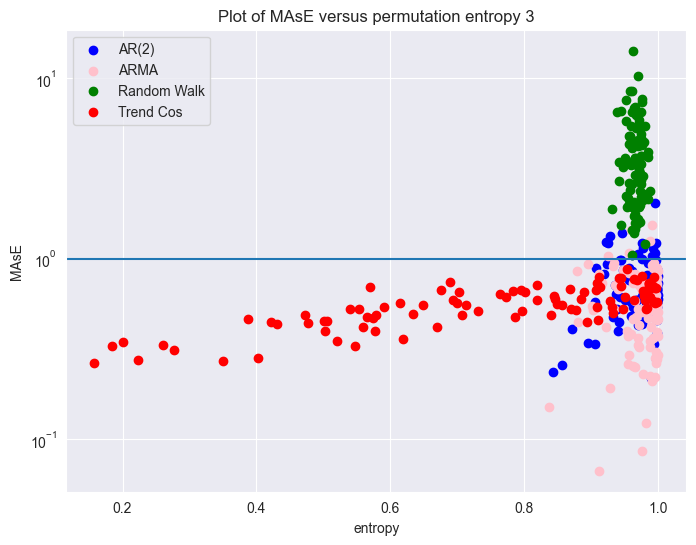

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(characteristics_df["ar2_perm_ent3"], metrics_df['ar2']['MASE'], color='blue', label='AR(2)')
plt.scatter(characteristics_df["arma_perm_ent3"], metrics_df['arma']['MASE'], color='pink', label='ARMA')
plt.scatter(characteristics_df["random_walk_perm_ent3"], metrics_df['random_walk']['MASE'], color='green', label='Random Walk')
plt.scatter(characteristics_df["trend_cos_perm_ent3"], metrics_df['trend_cos']['MASE'], color='red', label='Trend Cos')
plt.title('Plot of MAsE versus permutation entropy 3')
plt.axhline(y=1)
plt.xlabel('entropy')
plt.ylabel('MAsE')
plt.semilogy()
plt.grid(True)
plt.legend()
plt.show()

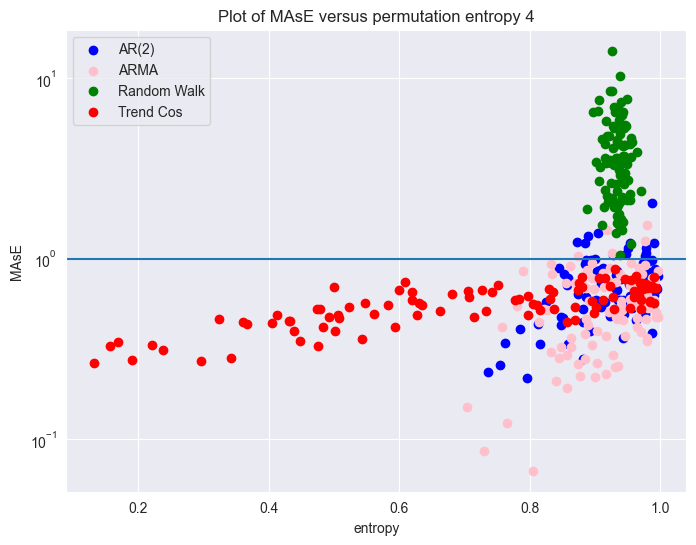

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(characteristics_df["ar2_perm_ent4"], metrics_df['ar2']['MASE'], color='blue', label='AR(2)')
plt.scatter(characteristics_df["arma_perm_ent4"], metrics_df['arma']['MASE'], color='pink', label='ARMA')
plt.scatter(characteristics_df["random_walk_perm_ent4"], metrics_df['random_walk']['MASE'], color='green', label='Random Walk')
plt.scatter(characteristics_df["trend_cos_perm_ent4"], metrics_df['trend_cos']['MASE'], color='red', label='Trend Cos')
plt.title('Plot of MAsE versus permutation entropy 4')
plt.axhline(y=1)
plt.xlabel('entropy')
plt.ylabel('MAsE')
plt.semilogy()
plt.grid(True)
plt.legend()
plt.show()

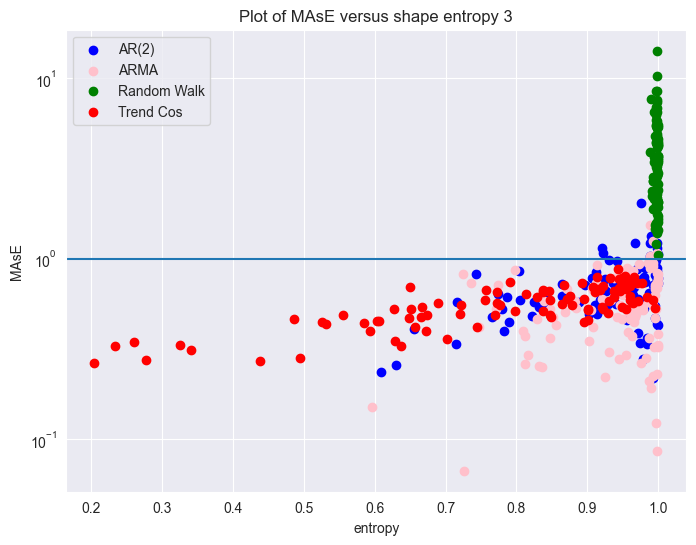

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(characteristics_df["ar2_shape_ent3"], metrics_df['ar2']['MASE'], color='blue', label='AR(2)')
plt.scatter(characteristics_df["arma_shape_ent3"], metrics_df['arma']['MASE'], color='pink', label='ARMA')
plt.scatter(characteristics_df["random_walk_shape_ent3"], metrics_df['random_walk']['MASE'], color='green', label='Random Walk')
#plt.scatter( characteristics_df["multifractal_perm_ent3"], metrics_df['multifractal']['SMAPE'], color='orange', label='Multifractal')
plt.scatter(characteristics_df["trend_cos_shape_ent3"], metrics_df['trend_cos']['MASE'], color='red', label='Trend Cos')
plt.title('Plot of MAsE versus shape entropy 3')
plt.axhline(y=1)
plt.xlabel('entropy')
plt.ylabel('MAsE')
plt.semilogy()
plt.grid(True)
plt.legend()
plt.show()
# plt.savefig(f'perm_ent3_MASE.png', bbox_inches='tight')
# plt.close()

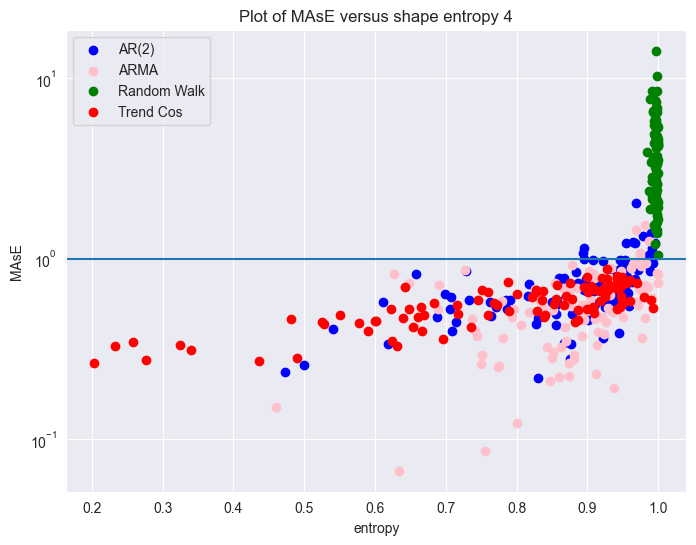

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(characteristics_df["ar2_shape_ent4"], metrics_df['ar2']['MASE'], color='blue', label='AR(2)')
plt.scatter(characteristics_df["arma_shape_ent4"], metrics_df['arma']['MASE'], color='pink', label='ARMA')
plt.scatter(characteristics_df["random_walk_shape_ent4"], metrics_df['random_walk']['MASE'], color='green', label='Random Walk')
#plt.scatter( characteristics_df["multifractal_perm_ent3"], metrics_df['multifractal']['SMAPE'], color='orange', label='Multifractal')
plt.scatter(characteristics_df["trend_cos_shape_ent4"], metrics_df['trend_cos']['MASE'], color='red', label='Trend Cos')
plt.title('Plot of MAsE versus shape entropy 4')
plt.axhline(y=1)
plt.xlabel('entropy')
plt.ylabel('MAsE')
plt.semilogy()
plt.grid(True)
plt.legend()
plt.show()
# plt.savefig(f'perm_ent3_MASE.png', bbox_inches='tight')
# plt.close()

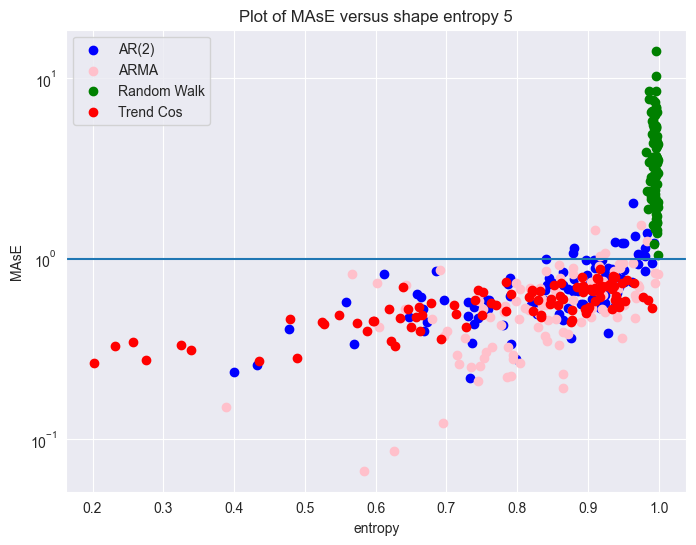

In [17]:
plt.figure(figsize=(8, 6))
plt.scatter(characteristics_df["ar2_shape_ent5"], metrics_df['ar2']['MASE'], color='blue', label='AR(2)')
plt.scatter(characteristics_df["arma_shape_ent5"], metrics_df['arma']['MASE'], color='pink', label='ARMA')
plt.scatter(characteristics_df["random_walk_shape_ent5"], metrics_df['random_walk']['MASE'], color='green', label='Random Walk')
#plt.scatter( characteristics_df["multifractal_perm_ent3"], metrics_df['multifractal']['SMAPE'], color='orange', label='Multifractal')
plt.scatter(characteristics_df["trend_cos_shape_ent5"], metrics_df['trend_cos']['MASE'], color='red', label='Trend Cos')
plt.title('Plot of MAsE versus shape entropy 5')
plt.axhline(y=1)
plt.xlabel('entropy')
plt.ylabel('MAsE')
plt.semilogy()
plt.grid(True)
plt.legend()
plt.show()
# plt.savefig(f'perm_ent3_MASE.png', bbox_inches='tight')
# plt.close()

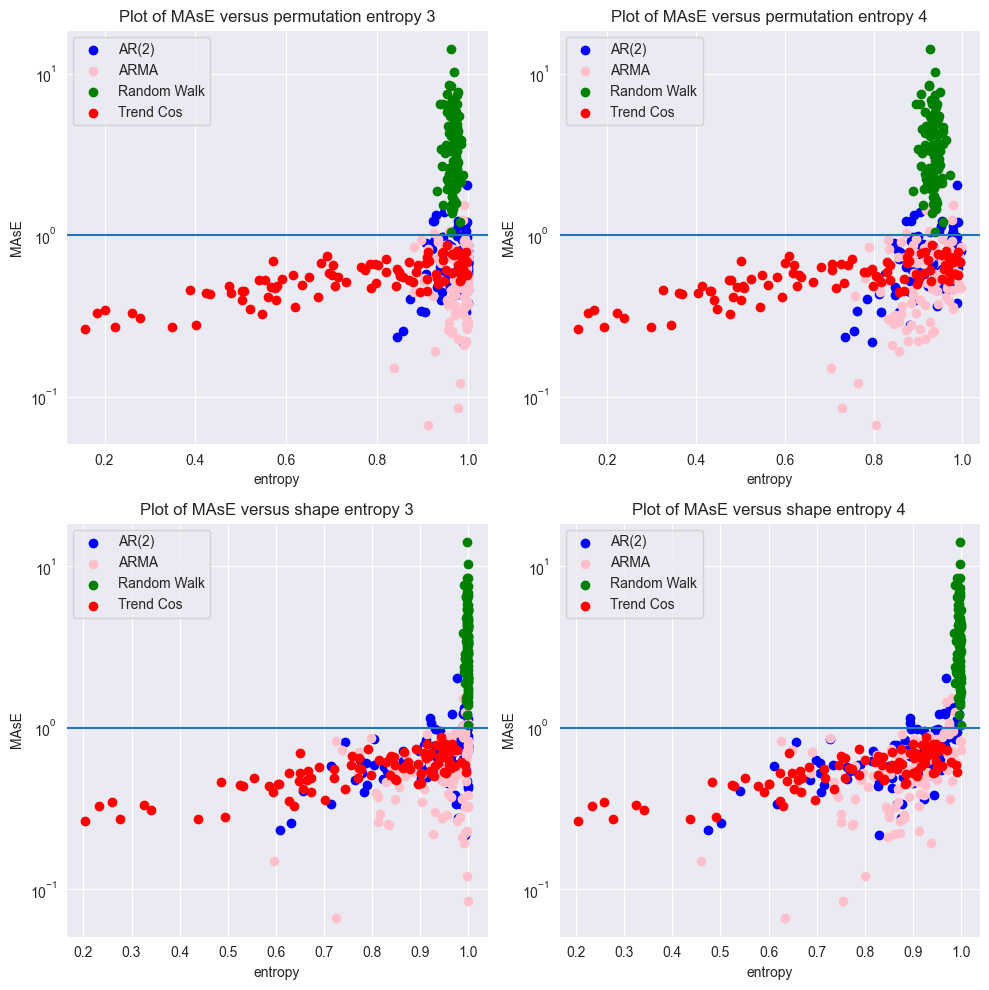

In [29]:
plt.figure(figsize=(10, 10))

# First subplot
plt.subplot(2, 2, 1)
plt.scatter(characteristics_df["ar2_perm_ent3"], metrics_df['ar2']['MASE'], color='blue', label='AR(2)')
plt.scatter(characteristics_df["arma_perm_ent3"], metrics_df['arma']['MASE'], color='pink', label='ARMA')
plt.scatter(characteristics_df["random_walk_perm_ent3"], metrics_df['random_walk']['MASE'], color='green', label='Random Walk')
plt.scatter(characteristics_df["trend_cos_perm_ent3"], metrics_df['trend_cos']['MASE'], color='red', label='Trend Cos')
plt.title('Plot of MAsE versus permutation entropy 3')
plt.axhline(y=1)
plt.xlabel('entropy')
plt.ylabel('MAsE')
plt.semilogy()
plt.grid(True)
plt.legend()

# Second subplot
plt.subplot(2, 2, 2)
plt.scatter(characteristics_df["ar2_perm_ent4"], metrics_df['ar2']['MASE'], color='blue', label='AR(2)')
plt.scatter(characteristics_df["arma_perm_ent4"], metrics_df['arma']['MASE'], color='pink', label='ARMA')
plt.scatter(characteristics_df["random_walk_perm_ent4"], metrics_df['random_walk']['MASE'], color='green', label='Random Walk')
plt.scatter(characteristics_df["trend_cos_perm_ent4"], metrics_df['trend_cos']['MASE'], color='red', label='Trend Cos')
plt.title('Plot of MAsE versus permutation entropy 4')
plt.axhline(y=1)
plt.xlabel('entropy')
plt.ylabel('MAsE')
plt.semilogy()
plt.grid(True)
plt.legend()

# Third subplot
plt.subplot(2, 2, 3)
plt.scatter(characteristics_df["ar2_shape_ent3"], metrics_df['ar2']['MASE'], color='blue', label='AR(2)')
plt.scatter(characteristics_df["arma_shape_ent3"], metrics_df['arma']['MASE'], color='pink', label='ARMA')
plt.scatter(characteristics_df["random_walk_shape_ent3"], metrics_df['random_walk']['MASE'], color='green', label='Random Walk')
plt.scatter(characteristics_df["trend_cos_shape_ent3"], metrics_df['trend_cos']['MASE'], color='red', label='Trend Cos')
plt.title('Plot of MAsE versus shape entropy 3')
plt.axhline(y=1)
plt.xlabel('entropy')
plt.ylabel('MAsE')
plt.semilogy()
plt.grid(True)
plt.legend()

# Fourth subplot
plt.subplot(2, 2, 4)
plt.scatter(characteristics_df["ar2_shape_ent4"], metrics_df['ar2']['MASE'], color='blue', label='AR(2)')
plt.scatter(characteristics_df["arma_shape_ent4"], metrics_df['arma']['MASE'], color='pink', label='ARMA')
plt.scatter(characteristics_df["random_walk_shape_ent4"], metrics_df['random_walk']['MASE'], color='green', label='Random Walk')
plt.scatter(characteristics_df["trend_cos_shape_ent4"], metrics_df['trend_cos']['MASE'], color='red', label='Trend Cos')
plt.title('Plot of MAsE versus shape entropy 4')
plt.axhline(y=1)
plt.xlabel('entropy')
plt.ylabel('MAsE')
plt.semilogy()
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig("ent_mase.png")
plt.show()


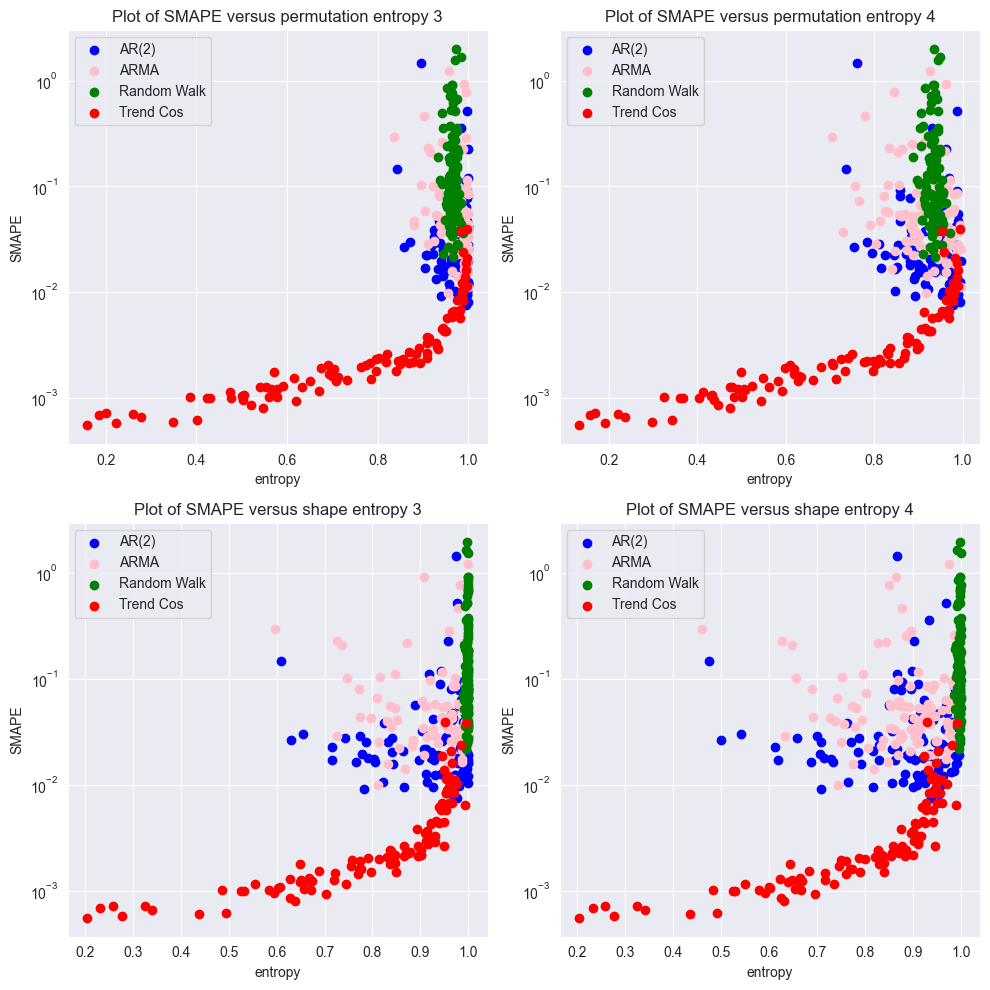

In [30]:
plt.figure(figsize=(10, 10))

# First subplot
plt.subplot(2, 2, 1)
plt.scatter(characteristics_df["ar2_perm_ent3"], metrics_df['ar2']['SMAPE'], color='blue', label='AR(2)')
plt.scatter(characteristics_df["arma_perm_ent3"], metrics_df['arma']['SMAPE'], color='pink', label='ARMA')
plt.scatter(characteristics_df["random_walk_perm_ent3"], metrics_df['random_walk']['SMAPE'], color='green', label='Random Walk')
plt.scatter(characteristics_df["trend_cos_perm_ent3"], metrics_df['trend_cos']['SMAPE'], color='red', label='Trend Cos')
plt.title('Plot of SMAPE versus permutation entropy 3')
plt.xlabel('entropy')
plt.ylabel('SMAPE')
plt.semilogy()
plt.grid(True)
plt.legend()

# Second subplot
plt.subplot(2, 2, 2)
plt.scatter(characteristics_df["ar2_perm_ent4"], metrics_df['ar2']['SMAPE'], color='blue', label='AR(2)')
plt.scatter(characteristics_df["arma_perm_ent4"], metrics_df['arma']['SMAPE'], color='pink', label='ARMA')
plt.scatter(characteristics_df["random_walk_perm_ent4"], metrics_df['random_walk']['SMAPE'], color='green', label='Random Walk')
plt.scatter(characteristics_df["trend_cos_perm_ent4"], metrics_df['trend_cos']['SMAPE'], color='red', label='Trend Cos')
plt.title('Plot of SMAPE versus permutation entropy 4')
plt.xlabel('entropy')
plt.ylabel('SMAPE')
plt.semilogy()
plt.grid(True)
plt.legend()

# Third subplot
plt.subplot(2, 2, 3)
plt.scatter(characteristics_df["ar2_shape_ent3"], metrics_df['ar2']['SMAPE'], color='blue', label='AR(2)')
plt.scatter(characteristics_df["arma_shape_ent3"], metrics_df['arma']['SMAPE'], color='pink', label='ARMA')
plt.scatter(characteristics_df["random_walk_shape_ent3"], metrics_df['random_walk']['SMAPE'], color='green', label='Random Walk')
plt.scatter(characteristics_df["trend_cos_shape_ent3"], metrics_df['trend_cos']['SMAPE'], color='red', label='Trend Cos')
plt.title('Plot of SMAPE versus shape entropy 3')
plt.xlabel('entropy')
plt.ylabel('SMAPE')
plt.semilogy()
plt.grid(True)
plt.legend()

# Fourth subplot
plt.subplot(2, 2, 4)
plt.scatter(characteristics_df["ar2_shape_ent4"], metrics_df['ar2']['SMAPE'], color='blue', label='AR(2)')
plt.scatter(characteristics_df["arma_shape_ent4"], metrics_df['arma']['SMAPE'], color='pink', label='ARMA')
plt.scatter(characteristics_df["random_walk_shape_ent4"], metrics_df['random_walk']['SMAPE'], color='green', label='Random Walk')
plt.scatter(characteristics_df["trend_cos_shape_ent4"], metrics_df['trend_cos']['SMAPE'], color='red', label='Trend Cos')
plt.title('Plot of SMAPE versus shape entropy 4')
plt.xlabel('entropy')
plt.ylabel('SMAPE')
plt.semilogy()
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig("ent_smape.png")
plt.show()


In [34]:
2**7

128

C:\Users\vitya\AppData\Local\Temp\ipykernel_14756\2263194291.py:51: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()


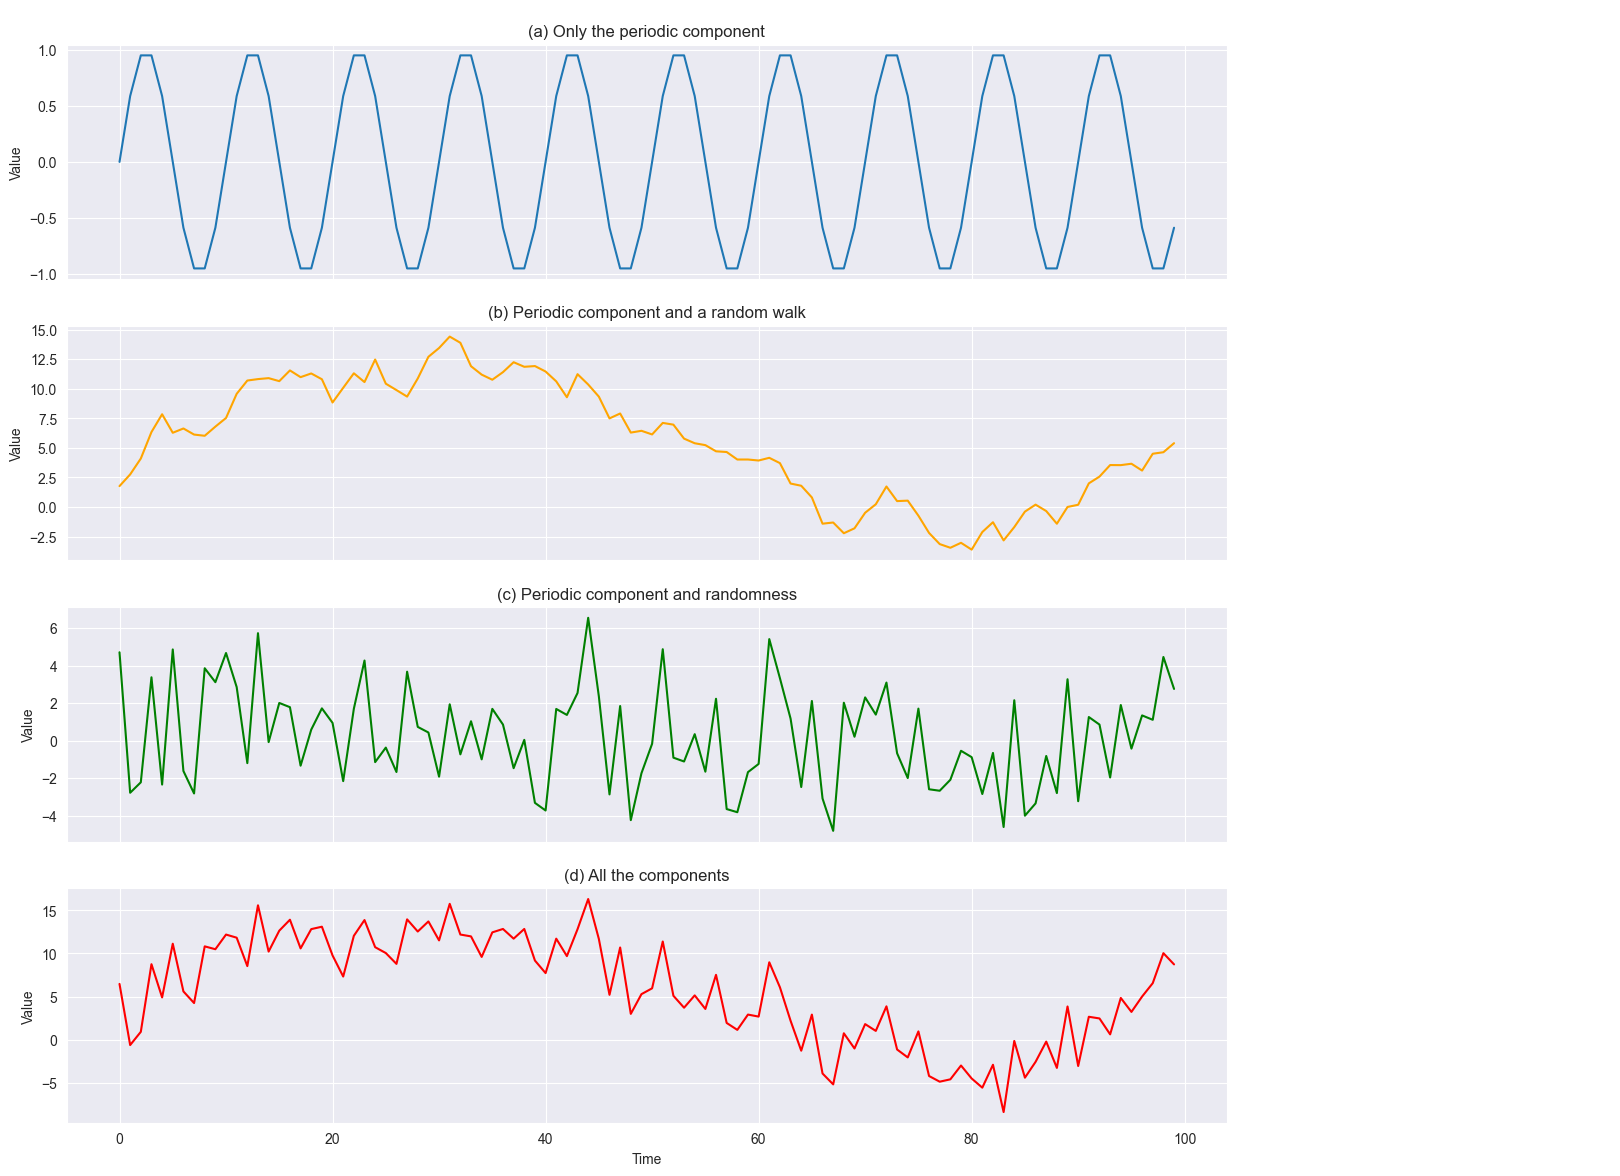

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
np.random.seed(0)
n = 100
t = np.arange(n)
frequency = 1/10

# Components
periodic_component = np.sin(2 * np.pi * frequency * t)
random_walk_component = np.cumsum(np.random.randn(n))
random_component = np.random.randn(n) * 2.5

# Series
series_a = periodic_component
series_b = periodic_component + random_walk_component
series_c = periodic_component + random_component
series_d = periodic_component + random_walk_component + random_component

# Plotting
fig, axs = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

axs[0].plot(t, series_a, label='Periodic Component')
axs[0].set_ylabel('Value')
axs[0].set_title('(a) Only the periodic component')

axs[1].plot(t, series_b, label='Periodic + Random Walk', color='orange')
axs[1].set_ylabel('Value')
axs[1].set_title('(b) Periodic component and a random walk')

axs[2].plot(t, series_c, label='Periodic + Randomness', color='green')
axs[2].set_ylabel('Value')
axs[2].set_title('(c) Periodic component and randomness')

axs[3].plot(t, series_d, label='All Components', color='red')
axs[3].set_ylabel('Value')
axs[3].set_title('(d) All the components')
axs[3].set_xlabel('Time')

# Adding predictability arrow
for ax in axs:
    ax.label_outer()

fig.subplots_adjust(right=0.85)
plt.annotate('Predictability', xy=(1.06, 0.1), xytext=(1.06, 0.9),
             xycoords='figure fraction', textcoords='figure fraction',
             arrowprops=dict(facecolor='black', shrink=0.05, width=2, headwidth=8),
             horizontalalignment='center', verticalalignment='center', fontsize=12)

plt.tight_layout()
plt.savefig("predictability.png")
plt.show()
